In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import time

In [2]:
# 设置显示所有的列
pd.options.display.max_columns = None

In [3]:
pwd

'D:\\Documents\\MyProjects\\DataAnalysis\\Kaggle\\House-price-regression-#1'

不知道为什么，cd命令的cell里不能有注释

mac路径

In [5]:
cd Kaggle/House-price-regression-#1/data

/Users/danielzhang/Documents/Python-Projects/DataAnalysis/Kaggle/House-price-regression-#1/data


windows路径

In [4]:
cd D:\\Documents\\MyProjects\\DataAnalysis\\Kaggle\\House-price-regression-#1\\data

D:\Documents\MyProjects\DataAnalysis\Kaggle\House-price-regression-#1\data


# EDA

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [6]:
train.set_index('Id', inplace=True)
test.set_index('Id', inplace=True)

print(train.shape)
print(test.shape)

(1460, 80)
(1459, 79)


In [7]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


+ 查看一下目标变量Sales的分布  
由下面可以看出，Sales是明显的偏态分布，这意味着有可能需要对它做**Box-Cox**变换

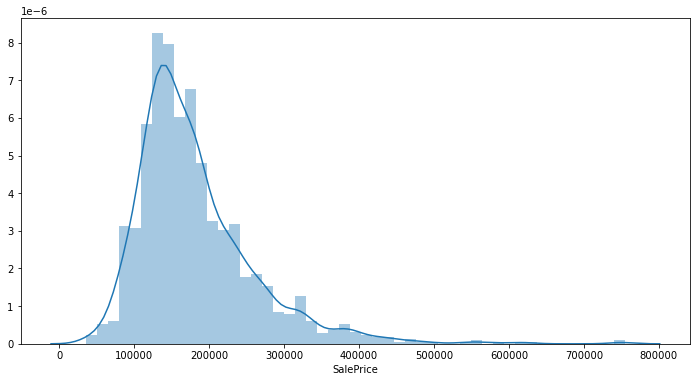

In [8]:
fig, ax = plt.subplots(figsize=(12,6))
sns.distplot(train['SalePrice'], ax=ax)

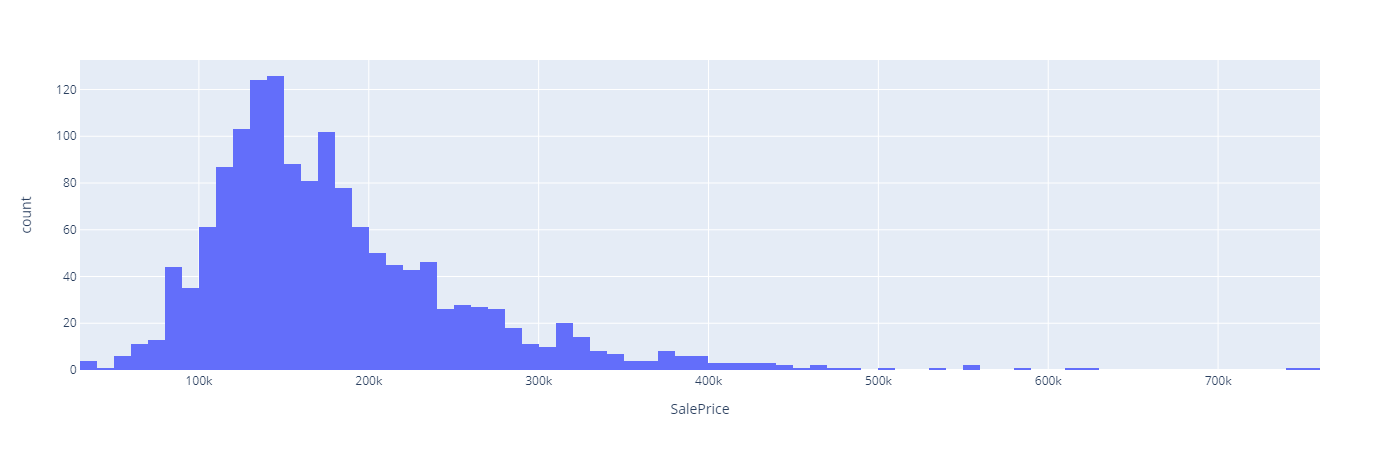

In [9]:
px.histogram(data_frame=train, x='SalePrice')

+ 初步探索各个变量和 SalesPrice 的相关性——相关性矩阵   

In [11]:
# 首先查看各个变量之间的相关系数，这里的相关系数只对数值特征进行计算
correlation_matrix = train.corr()

In [12]:
correlation_matrix.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

使用热力图来查看相关系数的情况

In [12]:
# 使用seaborn绘制
# fig, ax = plt.subplots(figsize=(12,12))
# sns.heatmap(correlation_matrix, ax=ax)

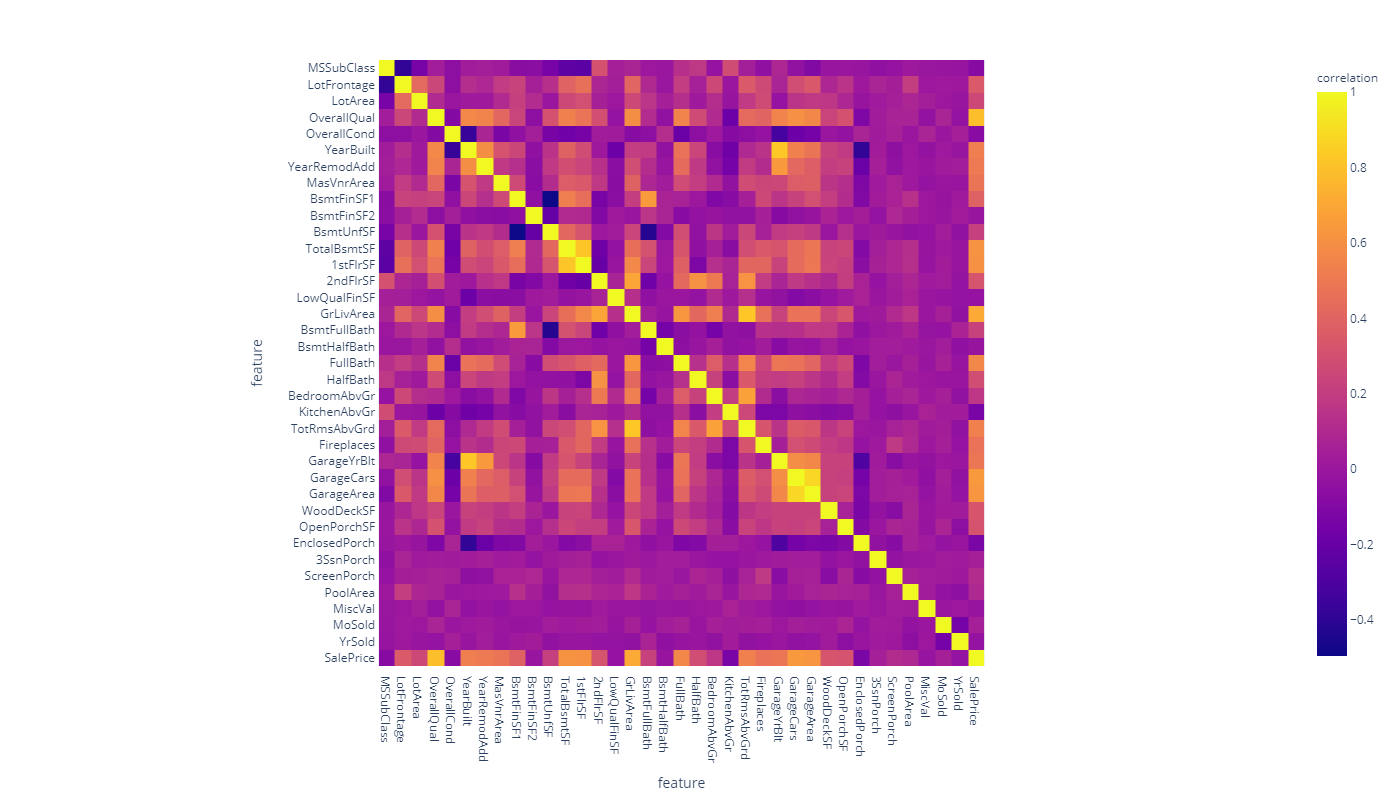

In [13]:
cols = correlation_matrix.columns
px.imshow(img=correlation_matrix, width=1000, height=800, x=cols, y=cols, labels={'x':'feature','y':'feature','color':'correlation'})
# trace = go.Heatmap()
# fig = go.Figure()

选择和SalePrice相关系数最高的前15个变量查看一下热力图

In [14]:
# 注意，这类是选择根据 SalePrice 降序的 top 10记录里，SalePrice 列的index，
# 不能直接选择DF，否则会出现 shape 的行数和列数不匹配的情况
correlation_top_index = correlation_matrix.nlargest(n=15, columns='SalePrice')['SalePrice'].index
correlation_top = train[correlation_top_index].corr()

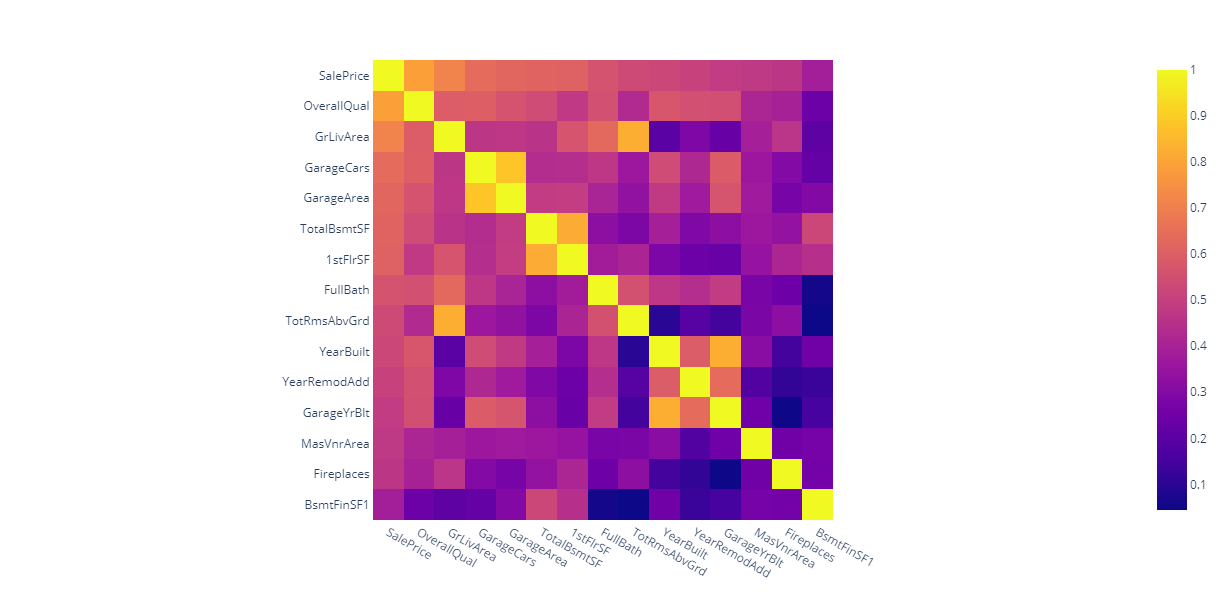

In [15]:
px.imshow(correlation_top, x=correlation_top_index, y=correlation_top_index, width=800, height=600)

In [16]:
correlation_top

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1
SalePrice,1.000000,0.790982,0.708624,0.640409,0.623431,0.613581,0.605852,0.560664,0.533723,0.522897,0.507101,0.486362,0.477493,0.466929,0.386420
OverallQual,0.790982,1.000000,0.593007,0.600671,0.562022,0.537808,0.476224,0.550600,0.427452,0.572323,0.550684,0.547766,0.411876,0.396765,0.239666
GrLivArea,0.708624,0.593007,1.000000,0.467247,0.468997,0.454868,0.566024,0.630012,0.825489,0.199010,0.287389,0.231197,0.390857,0.461679,0.208171
GarageCars,0.640409,0.600671,0.467247,1.000000,0.882475,0.434585,0.439317,0.469672,0.362289,0.537850,0.420622,0.588920,0.364204,0.300789,0.224054
GarageArea,0.623431,0.562022,0.468997,0.882475,1.000000,0.486665,0.489782,0.405656,0.337822,0.478954,0.371600,0.564567,0.373066,0.269141,0.296970
TotalBsmtSF,0.613581,0.537808,0.454868,0.434585,0.486665,1.000000,0.819530,0.323722,0.285573,0.391452,0.291066,0.322445,0.363936,0.339519,0.522396
1stFlrSF,0.605852,0.476224,0.566024,0.439317,0.489782,0.819530,1.000000,0.380637,0.409516,0.281986,0.240379,0.233449,0.344501,0.410531,0.445863
FullBath,0.560664,0.550600,0.630012,0.469672,0.405656,0.323722,0.380637,1.000000,0.554784,0.468271,0.439046,0.484557,0.276833,0.243671,0.058543
TotRmsAbvGrd,0.533723,0.427452,0.825489,0.362289,0.337822,0.285573,0.409516,0.554784,1.000000,0.095589,0.191740,0.148112,0.280682,0.326114,0.044316
YearBuilt,0.522897,0.572323,0.199010,0.537850,0.478954,0.391452,0.281986,0.468271,0.095589,1.000000,0.592855,0.825667,0.315707,0.147716,0.249503


从上面的相关系数热力图可以找到如下几个信息：  
1. 和SalePrice有较强的线性关系的变量有：  
OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd, YearBuilt, YearRemodAdd 这10个，它们的相关系数都在 0.5 以上；
2. 可能存在共线性关系的变量：  
GarageCars 和 GarageArea，  TotalBsmtSF 和 1stFlrSF， GrLivArea 和 TotRmsAbvGrd， YearBuilt 和 GarageYrBlt，这4对变量选择其中一个即可

这样，**前10个相关系数最高的特征里，选择的是 OverallQual, GrLivArea, GarageCars, ~GarageArea~, TotalBsmtSF, ~1stFlrSF~, FullBath, ~TotRmsAbvGrd~, YearBuilt, YearRemodAdd**.  
还有一个 GarageYrBlt 需要去除。

+ 选择最为相关的10个变量看一下 矩阵图  
Seaborn的pairplot绘图很慢，所以不能一次性查看太多变量的两两绘图  
这里也可以看出哪些变量可能有异常值

In [14]:
# cols = ['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','FullBath','TotRmsAbvGrd','YearBuilt','YearRemodAdd']
cols = ['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']

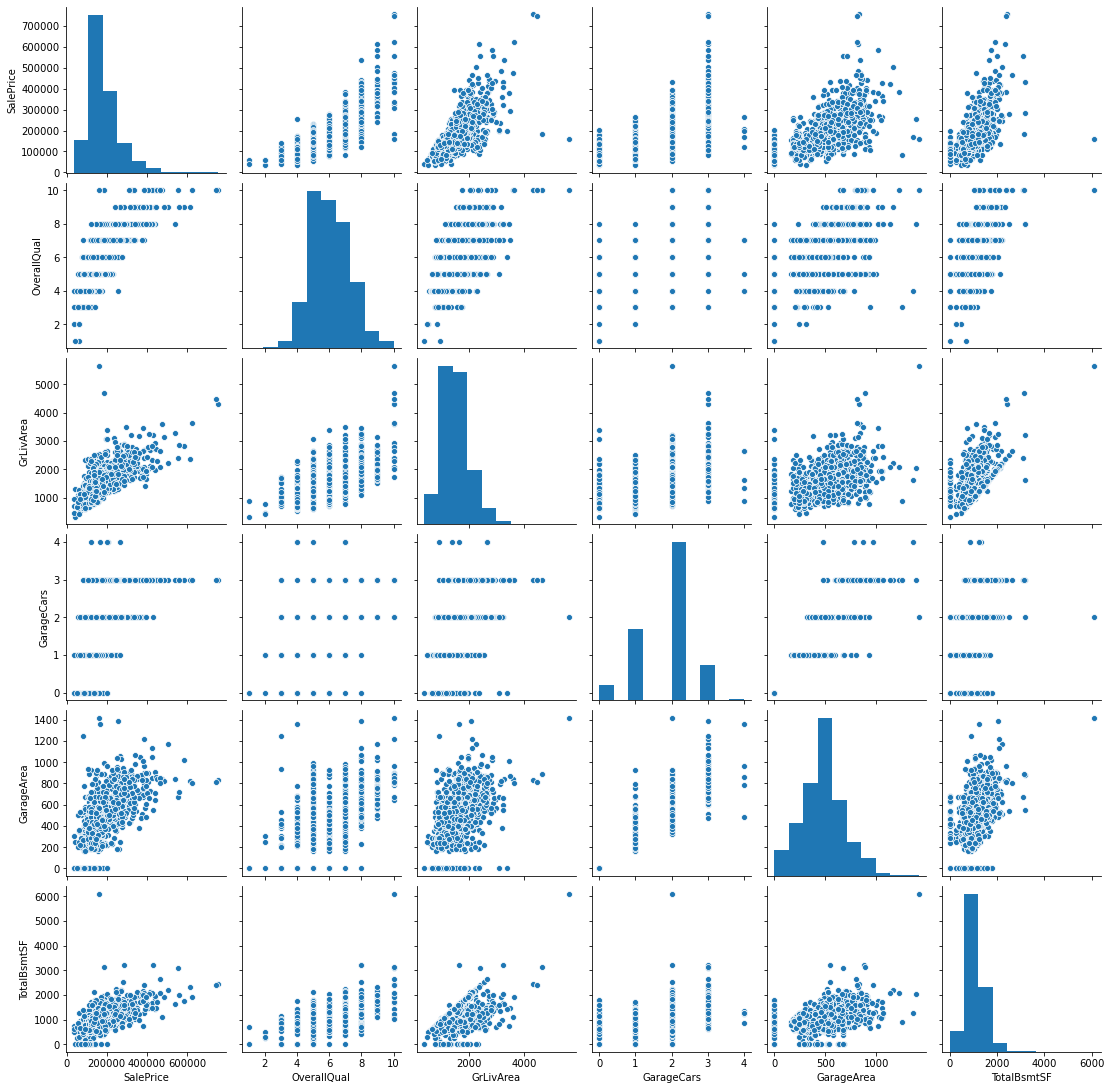

In [15]:
# fig, ax = plt.subplots(figsize=(12,6))
# sns.pairplot(train[correlation_top_index])
sns.pairplot(train[cols])

# 数据预处理

## 异常值

这里只对和Sales相关程度最高的5个变量进行异常值检测:  
'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF'

+ OverallQual，这是个有序离散特征  
不过不对这个特征下做任何处理

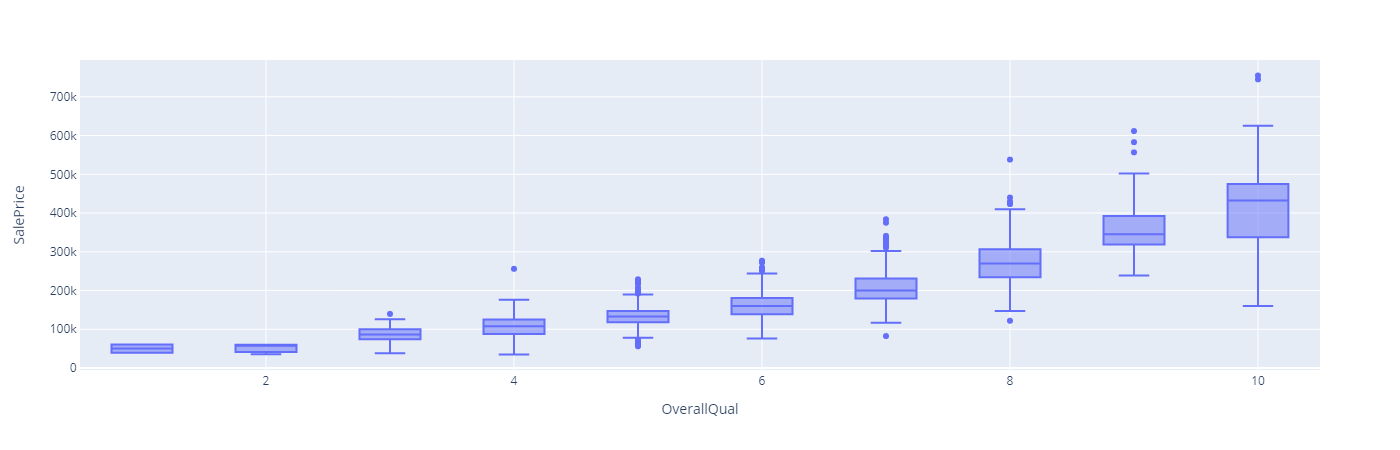

In [16]:
px.box(data_frame=train, x='OverallQual', y='SalePrice')

+ Sales和GrLivArea 
这里可以看出有两个异常值，GrLivArea = 4676 和 5642，需要删除

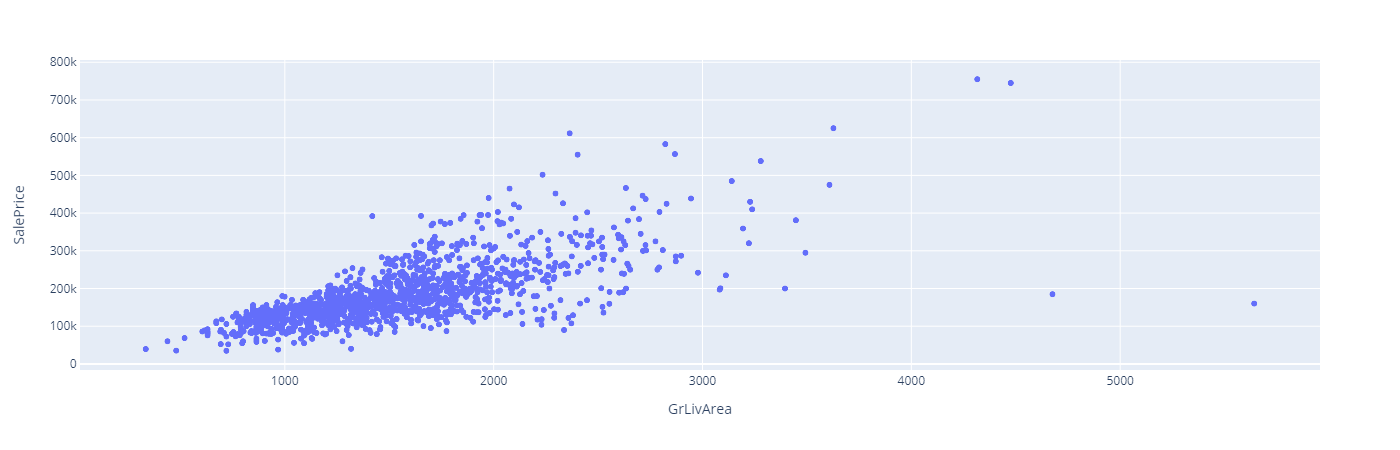

In [17]:
px.scatter(data_frame=train, x = 'GrLivArea', y = 'SalePrice')

+ GarageCars 和 GarageArea
这两个没有异常值

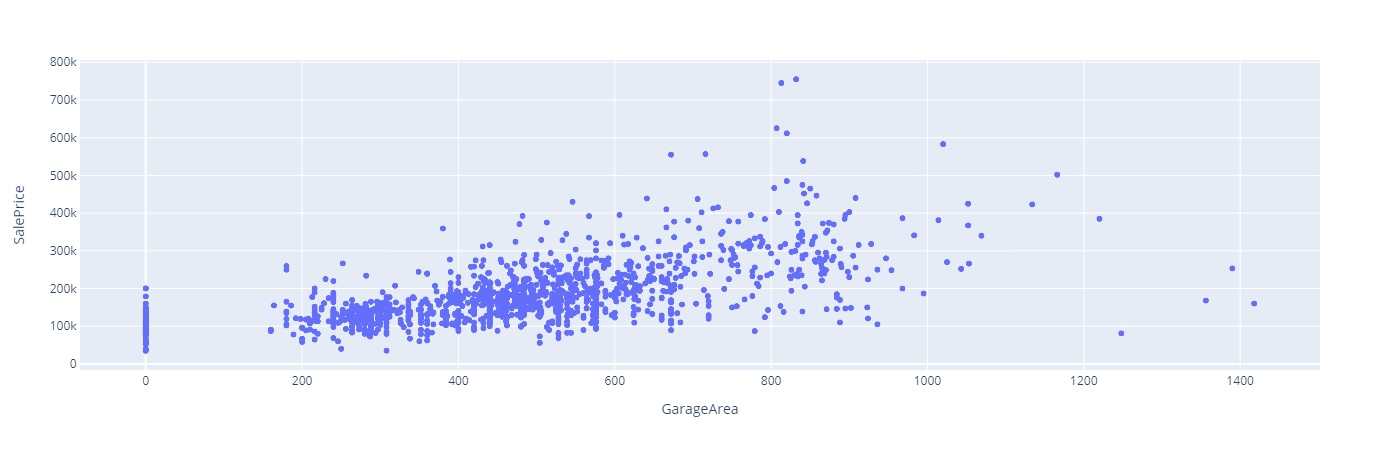

In [18]:
# px.scatter(data_frame=train, x = 'GarageCars', y = 'SalePrice')
px.scatter(data_frame=train, x = 'GarageArea', y = 'SalePrice')

+ Sales和TotalBsmtSF  
有一个异常值，TotalBsmtSF = 6110

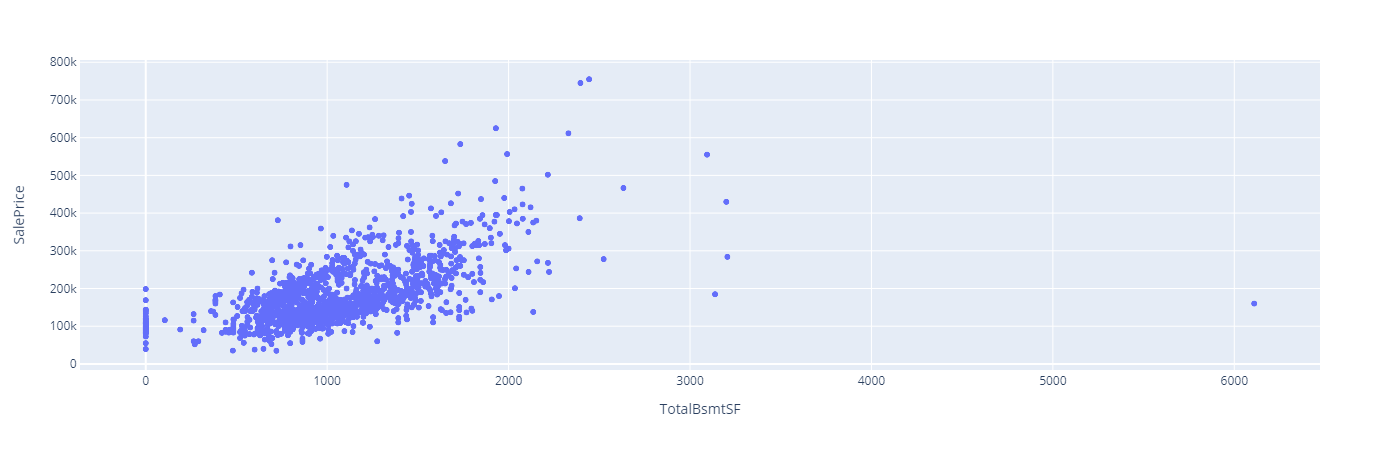

In [19]:
px.scatter(data_frame=train, x='TotalBsmtSF', y='SalePrice')

所以，最终要删除的异常值就三个：  
GrLivArea = 4676 和 5642， TotalBsmtSF = 6110

In [20]:
train = train[train['GrLivArea'] < 4600 ]
train = train[train['TotalBsmtSF'] < 6000]

检查一下结果

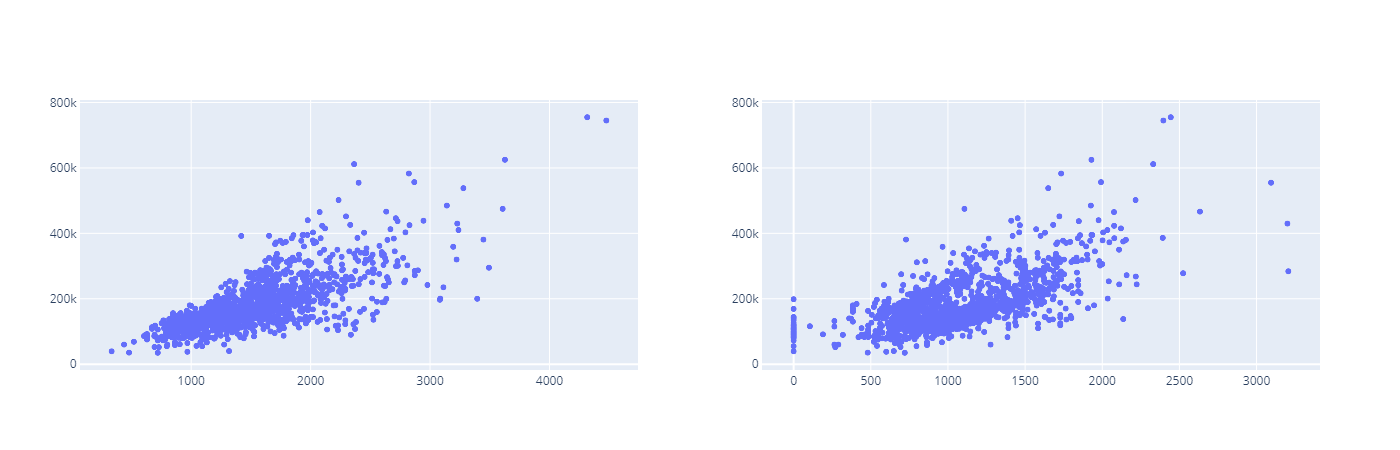

In [21]:
fig = make_subplots(1,2)
f1 = px.scatter(data_frame=train, x = 'GrLivArea', y = 'SalePrice')
f2 = px.scatter(data_frame=train, x='TotalBsmtSF', y='SalePrice')

fig.add_trace(f1.data[0], row=1, col=1)
fig.add_trace(f2.data[0], row=1, col=2)

fig.update_layout()
# fig.show()

## 缺失值

In [22]:
def miss_stat(df):
    """
    用于统计DF中各列的缺失值信息和占比
    """
    miss_num = df.isnull().sum()
    # miss_num[miss_num > 0].sort_values(ascending=False)
    total = df.shape[0]
    miss_persent = miss_num/total*100
    miss_info = pd.concat([miss_num, miss_persent, train.dtypes], axis = 1, keys=['miss_num', 'miss_percent','dtype'])
    miss_info['total'] = total
    miss_info = miss_info[['miss_num','total','miss_percent','dtype']]
#     降序排列，同时设置小数点的位数
    miss_info = miss_info.sort_values(by=['miss_num'],ascending=False).round(decimals=2)
#     打印
#     from IPython.display import display
#     display(miss_info[miss_info['miss_num'] > 0])  # 或者 print df.to_html()
#     print(miss_info[miss_info['miss_num'] > 0])
    return miss_info

def miss_stat_all(train, test):
    train_miss = miss_stat(train)
    test_miss = miss_stat(test)
    miss_info = train_miss.join(test_miss, lsuffix='_train', rsuffix='_test')
#     这里的逻辑与必须要使用pandas的 | ，而不是Python本身的 or
    miss_info = miss_info.loc[ (miss_info['miss_num_train'] > 0) | (miss_info['miss_num_test'] > 0), :].sort_values(by=['miss_num_train'],ascending=False)
    return miss_info

In [23]:
# miss_info = miss_stat(train)
# miss_info[miss_info['miss_num'] > 0]
miss_info = miss_stat_all(train, test)
miss_info

,miss_num_train,total_train,miss_percent_train,dtype_train,miss_num_test,total_test,miss_percent_test,dtype_test
PoolQC,1452,1458,99.59,object,1456.0,1459,99.79,object
MiscFeature,1404,1458,96.30,object,1408.0,1459,96.50,object
Alley,1367,1458,93.76,object,1352.0,1459,92.67,object
Fence,1177,1458,80.73,object,1169.0,1459,80.12,object
FireplaceQu,690,1458,47.33,object,730.0,1459,50.03,object
LotFrontage,259,1458,17.76,float64,227.0,1459,15.56,float64
GarageYrBlt,81,1458,5.56,float64,78.0,1459,5.35,float64
GarageCond,81,1458,5.56,object,78.0,1459,5.35,object
GarageType,81,1458,5.56,object,76.0,1459,5.21,object
GarageFinish,81,1458,5.56,object,78.0,1459,5.35,object


In [24]:
miss_info.index

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'LotFrontage',
       'GarageYrBlt', 'GarageCond', 'GarageType', 'GarageFinish', 'GarageQual',
       'BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'BsmtFinType1',
       'MasVnrType', 'MasVnrArea', 'Electrical', 'Utilities', 'TotalBsmtSF',
       'BsmtUnfSF', 'BsmtFinSF2', 'BsmtFinSF1', 'Exterior2nd', 'Exterior1st',
       'BsmtFullBath', 'SaleType', 'GarageArea', 'GarageCars', 'BsmtHalfBath',
       'KitchenQual', 'Functional', 'MSZoning'],
      dtype='object')

In [25]:
# 根据数据集的说明，下面这些列里的NA都表示None,
cols_none_object = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                    'GarageCond', 'GarageType', 'GarageFinish', 'GarageQual',
                   'BsmtFinType2', 'BsmtExposure', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
                   'MasVnrType']

# 下面这些列使用众数填充
cols_na_mode = ['Electrical','Exterior2nd', 'MSZoning', 'SaleType','KitchenQual','Functional', 'Exterior1st']

# 下面的列直接丢弃
cols_drop = ['Utilities']


# 下面这些列是数值列
cols_na_num = ['LotFrontage',   'MasVnrArea', 'GarageYrBlt', 'GarageArea', 'GarageCars',
               'BsmtFinSF1',  'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFinSF2',  'BsmtFullBath', 'BsmtHalfBath']

In [26]:
print( len(list(miss_info.index)) )
print( len(cols_none_object) + len(cols_na_num) +len(cols_na_mode) + len(cols_drop) )

34
34


+ 使用 None字符串 填充

In [27]:
for col in cols_none_object:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

+ 使用 众数 填充

In [28]:
for col in cols_na_mode:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

+ 直接丢弃的列

In [29]:
for col in cols_drop:
    train.drop(col, axis=1, inplace=True)
    test.drop(col, axis=1, inplace=True)

+ 数值列的填充

In [30]:
cols_num = ['MasVnrArea', 'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',  'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFinSF2',  'BsmtFullBath', 'BsmtHalfBath']
for col in cols_num:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)
    
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].mean())
test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].mean())

检查是否还有缺失值

In [31]:
miss_info_check = miss_stat_all(train, test)
miss_info_check.head()

,miss_num_train,total_train,miss_percent_train,dtype_train,miss_num_test,total_test,miss_percent_test,dtype_test


In [33]:
# 这里只丢弃了 Utilities 这一列
train.shape

(1458, 79)

## 特征工程

### 检查目标变量 SalePrice 的正态性

绘制KDE图

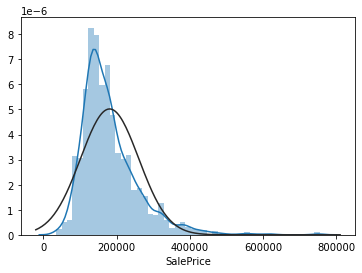

In [34]:
from scipy.stats import norm

sns.distplot(train['SalePrice'], fit=norm)

绘制Q-Q图

In [35]:
from scipy.stats import probplot
import statsmodels.api as sm

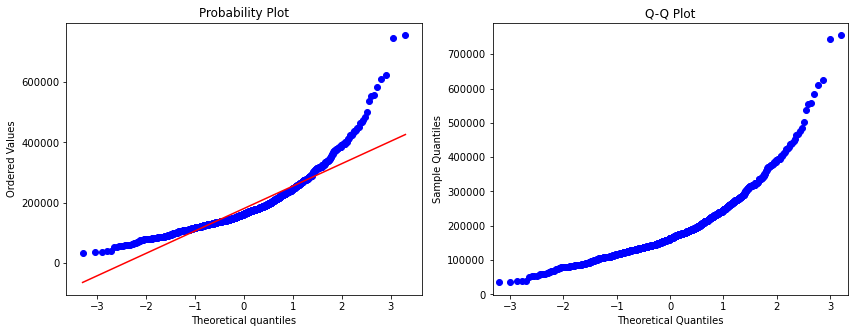

In [36]:
plt.ioff()
fig = plt.figure(figsize=(14,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

# 这一种绘制的其实不是严格的Q-Q图
probplot(train['SalePrice'], plot=ax1)

# 下面这个绘制的才是严格的Q-Q图
sm.qqplot(train['SalePrice'], ax=ax2)
ax2.set_title('Q-Q Plot')

plt.ion()

对 SalePrice 进行对数变换，再进行检查

In [40]:
train['SalePrice'] = np.log(train['SalePrice'])

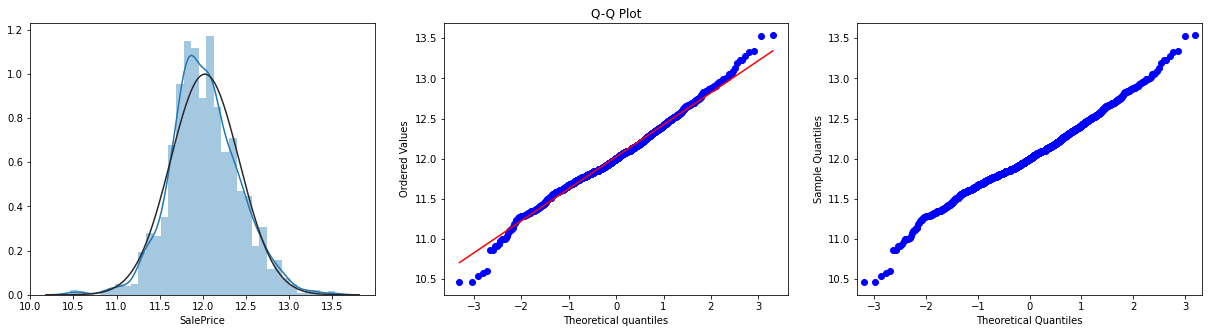

In [41]:
plt.ioff()
fig = plt.figure(figsize=(21,5))
ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

sns.distplot(train['SalePrice'], fit=norm, ax=ax1)

# 这一种绘制的其实不是严格的Q-Q图
probplot(train['SalePrice'], plot=ax2)

# 下面这个绘制的才是严格的Q-Q图
sm.qqplot(train['SalePrice'], ax=ax3)
ax2.set_title('Q-Q Plot')

plt.ion()

### 有序分类特征处理

In [155]:
train.select_dtypes(include='object').head()

,MSZoning,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,None,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
1,RL,Pave,None,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,None,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal
3,RL,Pave,None,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,None,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,None,None,None,WD,Abnorml
4,RL,Pave,None,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,None,None,None,WD,Normal


In [160]:
train.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [42]:
# 名义类别变量
cat_nominal = ['MSZoning','Street','Alley','LotShape','LandContour','LotConfig','Neighborhood','Condition1','Condition2','BldgType',
               'HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation','Heating','CentralAir',
               'Electrical','GarageType','MiscFeature','SaleType']

# 有序类别变量
cat_ordinal = ['LandSlope','ExterQual','ExterCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
               'BsmtFinType2','HeatingQC','KitchenQual','Functional',
               'FireplaceQu','GarageFinish','GarageQual','GarageCond','PavedDrive',
               'PoolQC','Fence','SaleCondition']

In [46]:
print("名义变量个数：",len(cat_nominal))
print("有序变量个数",len(cat_ordinal))
print("总计个数：", len(cat_nominal) + len(cat_ordinal))
print("train的分类变量个数：", train.select_dtypes(include='object').shape[1])

名义变量个数： 23
有序变量个数 19
总计个数： 42
train的分类变量个数： 42


In [48]:
# 对于分类有序变量，需要自己定义变量里取值的顺序映射
# Utilities = ['ELO','NoSeWa','NoSewr','AllPub']
LandSlope = ['Sev','Mod','Gtl']
ExterQual = ['Po','Fa','TA','Gd','Ex']
ExterCond = ['Po','Fa','TA','Gd','Ex']
BsmtQual = ['None','Po','Fa','TA','Gd','Ex']
BsmtCond = ['None','Po','Fa','TA','Gd','Ex']
BsmtExposure = ['None','No','Mn','Av','Gd']
BsmtFinType1 = ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ']
BsmtFinType2 = ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ']
HeatingQC = ['Po','Fa','TA','Gd','Ex']
KitchenQual = ['Po','Fa','TA','Gd','Ex']
Functional = ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ']
FireplaceQu = ['None', 'Po','Fa','TA','Gd','Ex' ]
GarageFinish = ['None','Unf','RFn','Fin']
GarageQual = ['None','Po','Fa','TA','Gd','Ex']
GarageCond = ['None','Po','Fa','TA','Gd','Ex']
PavedDrive = ['N','P','Y']
PoolQC = ['None','Fa','TA','Gd','Ex' ]
Fence = ['None','MnWw', 'GdWo', 'MnPrv','GdPrv']
SaleCondition = ['Partial','Family','Alloca','AdjLand','Abnorml','Normal']

cat_ordinal_ls = [LandSlope, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1,
                  BsmtFinType2, HeatingQC, KitchenQual, Functional, FireplaceQu, GarageFinish, GarageQual, GarageCond, PavedDrive,
                  PoolQC, Fence, SaleCondition]

print('有序分类变量个数', len(cat_ordinal_ls))

有序分类变量个数 19


进行序数编码

In [49]:
train_ordinal = train[cat_ordinal]
train_ordinal.shape

(1458, 19)

In [50]:
from sklearn.preprocessing import OrdinalEncoder
enc_ordinal = OrdinalEncoder(categories=cat_ordinal_ls)
enc_ordinal.fit(train_ordinal)

OrdinalEncoder(categories=[['Sev', 'Mod', 'Gtl'],
                           ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['None', 'No', 'Mn', 'Av', 'Gd'],
                           ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                           ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                           ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1',
                            'Typ'],
                           ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['None', 'Unf', 'RFn', 'Fin'],
                           ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
                           ['None', 'Po', 'Fa', 'TA'

In [51]:
train_ordinal_enc = pd.DataFrame(enc_ordinal.transform(train_ordinal), columns=train_ordinal.columns)

测试数据处理

In [53]:
test_ordinal = test[cat_ordinal]
test_ordinal_enc = pd.DataFrame(enc_ordinal.transform(test_ordinal), columns=test_ordinal.columns)

### 名义分类特征处理

直接使用 onehot 编码

In [54]:
train_nonimal = train[cat_nominal]
train_nonimal.shape

(1458, 23)

In [55]:
from sklearn.preprocessing import OneHotEncoder
enc_onehot = OneHotEncoder(drop='if_binary', sparse=False)
enc_onehot.fit(train_nonimal)
train_nonimal_enc = pd.DataFrame(enc_onehot.transform(train_nonimal), columns=enc_onehot.get_feature_names(train_nonimal.columns))

处理测试数据

In [57]:
test_nonimal = test[cat_nominal]
test_nonimal_enc = pd.DataFrame(enc_onehot.transform(test_nonimal), columns=enc_onehot.get_feature_names(train_nonimal.columns))

### 合并数据

In [93]:
train_num = train.select_dtypes(exclude=['object'])
train_num.shape

(1458, 37)

In [101]:
train_cat = pd.concat([train_ordinal_enc, train_nonimal_enc], axis=1)
# 这里要注意设置index，否则下面concat的时候会出现问题
train_cat.set_index(train_num.index, inplace=True)
train_cat.shape

(1458, 183)

In [102]:
train_df = pd.concat([train_num, train_cat], axis=1)
train_df.shape

(1458, 220)

In [103]:
train_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,SaleCondition,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Grvl,Alley_None,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,12.247694,2.0,3.0,2.0,4.0,3.0,1.0,6.0,1.0,4.0,3.0,7.0,0.0,2.0,3.0,3.0,2.0,0.0,0.0,5.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [106]:
test_num = test.select_dtypes(exclude=['object'])
test_cat = pd.concat([test_ordinal_enc, test_nonimal_enc], axis=1)
test_cat.set_index(test_num.index, inplace=True)

print(test_num.shape)
print(test_cat.shape)

(1459, 36)
(1459, 183)


In [107]:
test_df = pd.concat([test_num, test_cat], axis=1)
test_df.shape

(1459, 219)

In [108]:
test_df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,Functional,FireplaceQu,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,SaleCondition,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Grvl,Alley_None,Alley_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010,2.0,2.0,2.0,3.0,3.0,1.0,3.0,2.0,2.0,2.0,7.0,0.0,1.0,3.0,3.0,2.0,0.0,3.0,5.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0

# 建模

先从训练数据中分离出特征和目标变量

In [109]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']

划分测试集和训练集（训练+验证）

In [112]:
from sklearn.model_selection import train_test_split

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=29)

In [118]:
X_train.shape

(1020, 219)

In [119]:
X_test.shape

(438, 219)

## XGBoost模型

In [122]:
import xgboost as xgb
from xgboost import XGBRegressor as XGBR

from sklearn. model_selection import cross_val_score, GridSearchCV

In [123]:
dtrain = xgb.DMatrix(X_train,y_train)
dtest = xgb.DMatrix(X_test,y_test)

+ 先用XGBoost自带的库选择最佳的num_round

In [129]:
params = {
    'booster':'gbtree',
    'objective':'reg:squarederror',
    'eta':0.3,
    'gamma':0,
    'max_depth':3,
    'lambda':1,
    'alpha':0,
    'subsample':1,
    'eval_metric':['rmse']
}

num_round = 200

watch_list = [(dtrain, 'train'),(dtest, 'test')]

# bst = xgb.train(params=params, dtrain=dtrain, num_boost_round=num_round, evals=watch_list )

history = xgb.cv(params=params, dtrain=dtrain, num_boost_round=num_round, nfold=5)

In [132]:
history.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std,num_round
0,8.087388,0.005351,8.087334,0.032480,1
1,5.671325,0.003881,5.671247,0.034301,2
2,3.979678,0.002791,3.979585,0.032135,3
3,2.795968,0.002104,2.796277,0.028639,4
4,1.967618,0.001415,1.968190,0.024814,5


In [133]:
history['num_round'] = np.arange(1,201)

train_info = history.loc[:, ['num_round','train-rmse-mean','train-rmse-std']]
test_info = history.loc[:, ['num_round','test-rmse-mean','test-rmse-std']]

train_info.columns = ['num_round','rmse-mean','rmse-std']
test_info.columns = ['num_round','rmse-mean','rmse-std']
train_info['type'] = 'train'
test_info['type'] = 'test'

history_info = pd.concat([train_info, test_info], axis = 0)

In [134]:
history_info.head()

,num_round,rmse-mean,rmse-std,type
0,1,8.087388,0.005351,train
1,2,5.671325,0.003881,train
2,3,3.979678,0.002791,train
3,4,2.795968,0.002104,train
4,5,1.967618,0.001415,train


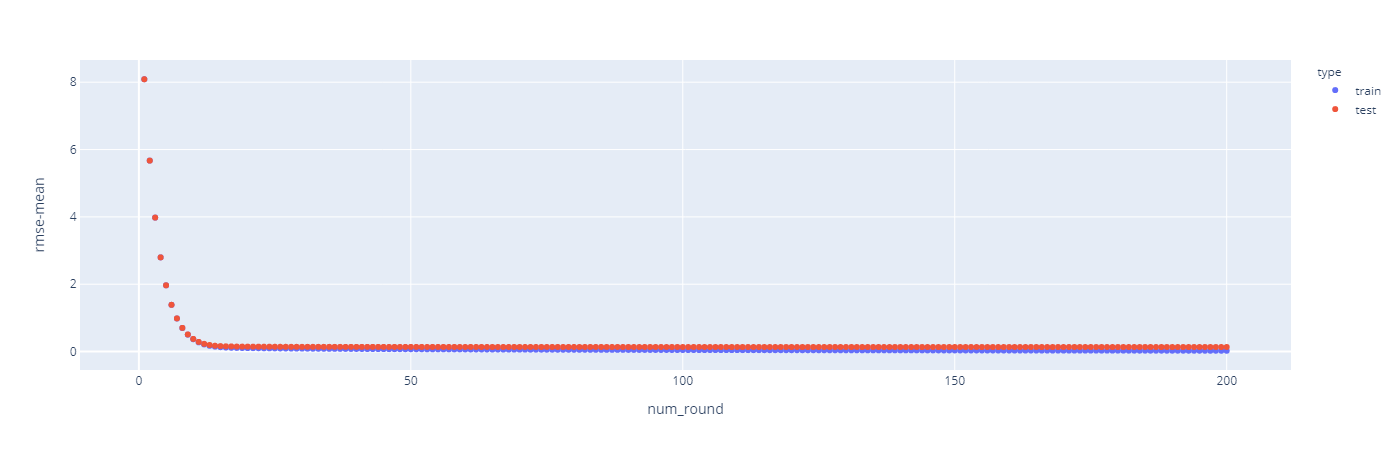

In [135]:
px.scatter(data_frame=history_info, x = 'num_round', y='rmse-mean',color='type')

+ 使用Sklearn接口调试

In [141]:
param_grid = {
    'n_estimators':np.arange(20,200, 5)
}

In [142]:
xgbr_cv = GridSearchCV(
    XGBR(booster='gbtree',objective='reg:squarederror',  random_state=29),
    param_grid = param_grid,
    n_jobs = -1,
    cv = 5,
    scoring = 'neg_mean_squared_error'
)

In [143]:
%%time
xgbr_cv.fit(X_train, y_train)

Wall time: 24.7 s


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster='gbtree',
                                    colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, gamma=None,
                                    gpu_id=None, importance_type='gain',
                                    interaction_constraints=None,
                                    learning_rate=None, max_delta_step=None,
                                    max_depth=None, min_child_weight=None,
                                    missing=nan, monotone_constraints=None,
                                    n_estimators=100, n_j...
                                    num_parallel_tree=None, random_state=29,
                                    reg_alpha=None, reg_lambda=None,
                                    scale_pos_weight=None, subsample=None,
                                    tree_method=None, validate_paramete

In [144]:
xgbr_cv.best_estimator_

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.300000012, max_delta_step=0, max_depth=6,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=165, n_jobs=0, num_parallel_tree=1, random_state=29,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [146]:
cv_results = xgbr_cv.cv_results_
# cv_results
cv_results_df = pd.DataFrame(cv_results)
cv_results_df.shape

(36, 14)

In [147]:
cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.253599,0.014180,0.007000,0.001095,20,{'n_estimators': 20},-0.025889,-0.029384,-0.024090,-0.013214,-0.018980,-0.022311,0.005654,36
1,0.331797,0.017406,0.007400,0.000490,25,{'n_estimators': 25},-0.025837,-0.027533,-0.022526,-0.012329,-0.018463,-0.021338,0.005467,35
2,0.408399,0.016776,0.007201,0.000401,30,{'n_estimators': 30},-0.025218,-0.027239,-0.022067,-0.012559,-0.018147,-0.021046,0.005239,34
3,0.471399,0.019085,0.008200,0.001470,35,{'n_estimators': 35},-0.025203,-0.026769,-0.021687,-0.012206,-0.018313,-0.020836,0.005212,33
4,0.545999,0.018857,0.006800,0.000400,40,{'n_estimators': 40},-0.024652,-0.026627,-0.021506,-0.012046,-0.018445,-0.020655,0.005126,32


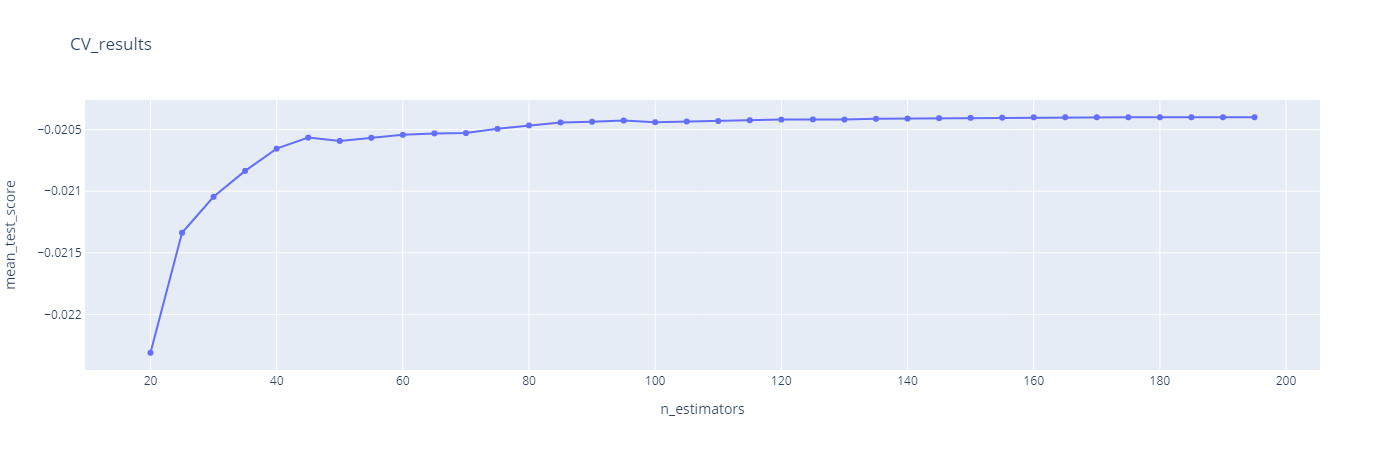

In [148]:
trace=go.Scatter(x=cv_results_df['param_n_estimators'], y=cv_results_df['mean_test_score'], mode='lines+markers', name='CV_results')
layout = go.Layout(
    title='CV_results',
    xaxis=go.layout.XAxis(title='n_estimators'),
    yaxis=go.layout.YAxis(title='mean_test_score')
)
fig = go.Figure(data=trace,layout=layout)

fig.show()